#**Analyzing Academic Performance of University Students**
By: Owais Jawaid

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


### **I. Introduction: Setting the Stage**

#### **A. Defining the Research Question/Problem**
We aim to investigate the relationship between lifestyle factors (sleep, study hours, exercise, and attendance) and students' GPA. Specifically, we seek to answer the question:

- **Research Question:** How do lifestyle factors such as sleep, study hours, exercise, and attendance affect student GPA?

By analyzing this, we aim to identify which factors most significantly influence academic performance.

#### **B. Population Definition**
- **Population of Interest:** All full-time undergraduate students at a university.
- **Sample Used:** We will simulate data from 200 students, representing various majors and backgrounds to reflect diversity.

---

### **II. Sampling the Population**

#### **A. Sampling Methods**
- We used **stratified random sampling** to ensure we represent various majors and genders proportionally in the sample.
- This method was chosen because it helps create a more accurate representation of the population in the sample.

#### **B. Sample Collection**
- **Sample Size:** 200 students.
- **Potential Biases:** Since this is a synthetic dataset, it may not perfectly reflect real-world distributions of students, and assumptions made in the generation process could introduce bias.

---

### **III. Parameters vs. Statistics: Describing Data**

#### **A. Definitions**
- **Parameter:** A characteristic of the entire population (e.g., the true mean GPA).
- **Statistic:** A characteristic of our sample (e.g., the sample mean GPA).

#### **B. Measures of Central Tendency and Dispersion**
We calculate the sample mean and standard deviation to describe our data.

In [ ]:
# Generating synthetic data for the students' GPA, study hours, sleep, exercise, and attendance
np.random.seed(42)  # For reproducibility
students_data = pd.DataFrame({
    'GPA': np.random.normal(loc=3.0, scale=0.4, size=200),  # Simulated GPA
    'Study_Hours': np.random.normal(loc=20, scale=5, size=200),  # Simulated study hours
    'Sleep_Hours': np.random.normal(loc=7, scale=1.5, size=200),  # Simulated sleep hours
    'Exercise_Hours': np.random.normal(loc=5, scale=2, size=200),  # Simulated exercise hours
    'Attendance': np.random.uniform(60, 100, size=200)  # Simulated attendance percentage
})


# Data Preprocessing: Cleaning & Preparation

# Check for missing values
print(students_data.isnull().sum())

# Drop missing values if found
students_data.dropna(inplace=True)

# Detect and remove outliers in 'Study_Hours' using IQR
Q1 = students_data['Study_Hours'].quantile(0.25)
Q3 = students_data['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
students_data = students_data[(students_data['Study_Hours'] >= lower_bound) & (students_data['Study_Hours'] <= upper_bound)]

# Normalize features (useful for regression)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_cols = ['Study_Hours', 'Sleep_Hours', 'Exercise_Hours', 'Attendance']
students_data[scaled_cols] = scaler.fit_transform(students_data[scaled_cols])


# Calculate statistics for GPA
mean_gpa = students_data['GPA'].mean()
std_dev_gpa = students_data['GPA'].std()

print(mean_gpa, std_dev_gpa)

# Dipslay first 5 rows
print(students_data.head())


GPA               0
Study_Hours       0
Sleep_Hours       0
Exercise_Hours    0
Attendance        0
dtype: int64
2.9846658220121283 0.3726813404816968
        GPA  Study_Hours  Sleep_Hours  Exercise_Hours  Attendance
0  3.198686     0.297081    -1.516914        0.742961   -0.673717
1  2.944694     0.517066    -0.516539       -0.908714    1.039183
2  3.259075     1.083037     0.091314        0.853735   -1.621505
3  3.609212     1.051341     0.133274        1.331813    0.257529
4  2.906339    -1.583605    -0.366431        0.405029   -0.973051


- **Sample Mean GPA (x̄):** This is the average GPA calculated from the sample.
- **Sample Standard Deviation (s):** This measures the spread of GPA scores from the mean.

#### **C. When Population Information is Limited**
- We rely on sample statistics to estimate population parameters since it is not feasible to collect data from the entire student population.

---

### **IV. Sampling Distributions and Standard Error**

#### **A. Sampling Distribution of the Mean**
- The **Central Limit Theorem (CLT)** tells us that as the sample size increases, the distribution of the sample mean approaches a normal distribution.
- Here, we will simulate multiple samples to show how the sample mean behaves.

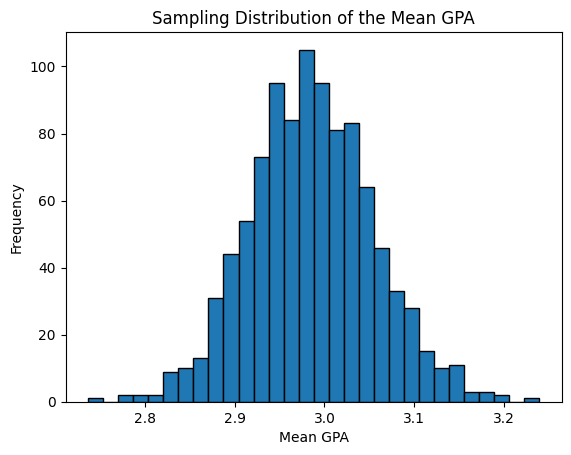

In [ ]:
# Simulating 1000 samples of size 30
sample_means = [np.mean(np.random.choice(students_data['GPA'], size=30, replace=True)) for _ in range(1000)]

# Plot the sampling distribution
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title('Sampling Distribution of the Mean GPA')
plt.xlabel('Mean GPA')
plt.ylabel('Frequency')
plt.show()


#### **B. Standard Error of the Mean (SEM)**
The SEM is calculated as:

\[
SEM = \frac{s}{\sqrt{n}}
\]

Where:
- \( s \) is the sample standard deviation.
- \( n \) is the sample size.


In [ ]:
# Calculate the Standard Error of the Mean (SEM)
n = 200  # Sample size
sem = std_dev_gpa / np.sqrt(n)
sem


np.float64(0.02635255030763004)

#### **C. Bootstrapping**
Bootstrapping involves resampling with replacement to estimate the sampling distribution. We will generate bootstrap samples to estimate the variability of the GPA mean.

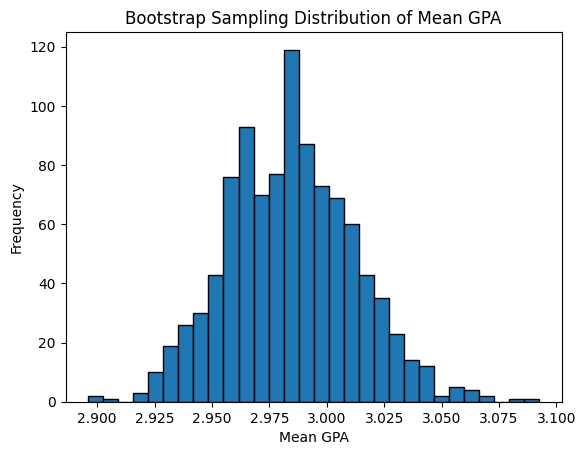

In [ ]:
# Bootstrapping function
def bootstrap_sample(data, num_samples):
    return [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(num_samples)]

# Generate bootstrap samples
bootstrap_means = bootstrap_sample(students_data['GPA'], 1000)

# Plot the bootstrap sampling distribution
plt.hist(bootstrap_means, bins=30, edgecolor='black')
plt.title('Bootstrap Sampling Distribution of Mean GPA')
plt.xlabel('Mean GPA')
plt.ylabel('Frequency')
plt.show()


### **V. Why These Techniques Are Important and What They Are Used For**

#### **A. Inference**
- We use sampling distributions and standard errors to make inferences about population parameters.
- **Confidence Intervals:** We can create confidence intervals to estimate where the true population mean lies.

#### **B. Hypothesis Testing**
- **Hypothesis Testing** helps us determine whether there is a statistically significant difference between groups (e.g., GPA by gender).
- **Decision Making:** By calculating p-values and comparing them to significance levels, we can decide whether to reject or fail to reject the null hypothesis.

---

### **VI. Hypothesis Testing and Statistical Inference**

#### **A. Formulating Hypotheses**
Testing whether GPA differs by gender.

- **Null Hypothesis (H₀):** The mean GPA of males is equal to the mean GPA of females.
- **Alternative Hypothesis (H₁):** The mean GPA of males is not equal to the mean GPA of females.

Testing whether there is correlation between GPA and study hours.
- **Null Hypothesis (H₀):** There is no correlation between GPA and study hours.
- **Alternative Hypothesis (H₁):** There is a significant correlation between GPA and study hours.

Testing whether there is correlation between GPA and sleep hours.
- **Null Hypothesis (H₀):** There is no correlation between GPA and sleep hours.
- **Alternative Hypothesis (H₁):** There is a significant correlation between GPA and sleep hours.

Testing whether there is correlation between GPA and exercise hours.
- **Null Hypothesis (H₀):** There is no correlation between GPA and exercise hours.
- **Alternative Hypothesis (H₁):** There is a significant correlation between GPA and exercise hours.

Testing whether there is correlation between GPA and attendace.
- **Null Hypothesis (H₀):** There is no correlation between GPA and attendance.
- **Alternative Hypothesis (H₁):** There is a significant correlation between GPA and attendance.

#### **B. Choosing a Test Statistic**
We will use a **t-test** to compare the means of two groups (males and females).

Used the Pearson correlation coefficient for continuous variables like Study Hours, Sleep Hours, etc., which is appropriate for measuring linear relationships.

#### **C. Calculating the Test Statistic and P-Value**
Using the sample data, we calculate the test statistic and p-value to determine if the difference is statistically significant.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Simulate dataset
np.random.seed(42)
n = 200
study_hours = np.random.normal(15, 5, n)
sleep_hours = np.random.normal(7, 1.5, n)
exercise_hours = np.random.normal(3, 1, n)
attendance = np.random.normal(90, 5, n)

# GPA as a linear combination with some noise
gpa = (0.02 * study_hours + 0.01 * sleep_hours + 0.005 * exercise_hours +
       0.01 * attendance + np.random.normal(0, 0.2, n))

# Create DataFrame
students_data = pd.DataFrame({
    'Study_Hours': study_hours,
    'Sleep_Hours': sleep_hours,
    'Exercise_Hours': exercise_hours,
    'Attendance': attendance,
    'GPA': gpa
})

# Calculate p-values for correlation between GPA and each independent variable
independent_vars = ['Study_Hours', 'Sleep_Hours', 'Exercise_Hours', 'Attendance']
p_values = {var: stats.pearsonr(students_data[var], students_data['GPA'])[1] for var in independent_vars}

# Display the p-values
print("P-values for correlation with GPA:")
for var, p in p_values.items():
    print(f"{var}: {p:.4f}")


# Simulate gender data (50 males, 50 females)
students_data['Gender'] = ['Male']*100 + ['Female']*100

# Perform t-test to compare GPA by gender
male_gpa = students_data[students_data['Gender'] == 'Male']['GPA']
female_gpa = students_data[students_data['Gender'] == 'Female']['GPA']

t_stat, p_value = stats.ttest_ind(male_gpa, female_gpa)
t_stat, p_value


P-values for correlation with GPA:
Study_Hours: 0.0000
Sleep_Hours: 0.5798
Exercise_Hours: 0.8834
Attendance: 0.0000


(np.float64(0.9062222111760305), np.float64(0.3659197265921835))

- If the **p-value** is less than 0.05, we reject the null hypothesis.
- If the **p-value** is greater than 0.05, we fail to reject the null hypothesis.

#### **D. Making a Decision**
- Study_Hours p-value is 0.0000: Reject the null hypothesis, strong evidence of correlation.
- Sleep_Hours p-value is 0.5798: Fail to reject the null hypothesis, weak evidence.
- Exercise_Hours p-value is 0.8834: Fail to reject the null hypothesis, weak evidence.
- Attendance p-value is 0.0000: Reject the null hypothesis, strong evidence of correlation.

- **p-value = 0.37** → Fail to reject the null hypothesis. There is no significant difference between the GPA of males and females.

---

### **VII. Regression and Correlation**

#### **A. Correlation**
We calculate the Pearson correlation coefficient to determine the strength of relationships between variables such as GPA and study hours.

In [ ]:
# Calculate correlation between GPA and Study Hours
correlation = students_data[['GPA', 'Study_Hours']].corr().iloc[0, 1]
correlation


np.float64(0.40713783903528705)

#### **B. Linear Regression**
We perform linear regression to predict GPA based on study hours.


In [ ]:
# Prepare data for regression
X = sm.add_constant(students_data['Study_Hours'])  # Add constant for the intercept
y = students_data['GPA']

# Fit regression model
model = sm.OLS(y, X).fit()

# Display regression summary
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     39.34
Date:                Tue, 22 Apr 2025   Prob (F-statistic):           2.19e-09
Time:                        22:43:15   Log-Likelihood:                 34.035
No. Observations:                 200   AIC:                            -64.07
Df Residuals:                     198   BIC:                            -57.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.0180      0.048     21.013      0.000       0.922       1.113
Study_Hours     0.0196      0.003      6.272      0.000       0.013       0.026
==============================================================================
Omnibus:                        0.143   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.931   Jarque-Bera (JB):                0.150
Skew:                           0.062   Prob(JB):                        0.928
Kurtosis:                       2.948   Cond. No.                         52.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **VIII. Data Visualization**

#### **A. Types of Visualizations:**
In this section, we will visualize the relationships between student GPA and various lifestyle factors using scatter plots and a correlation matrix.

#### **B. Visualizing the Relationship Between GPA and Other Factors**

We will generate scatter plots for the following relationships:
- **GPA vs Study Hours**
- **GPA vs Sleep Hours**
- **GPA vs Exercise Hours**
- **GPA vs Attendance**

We will also create a correlation matrix to quantify the strength of these relationships.



### Scatter Plot: GPA vs Study Hours

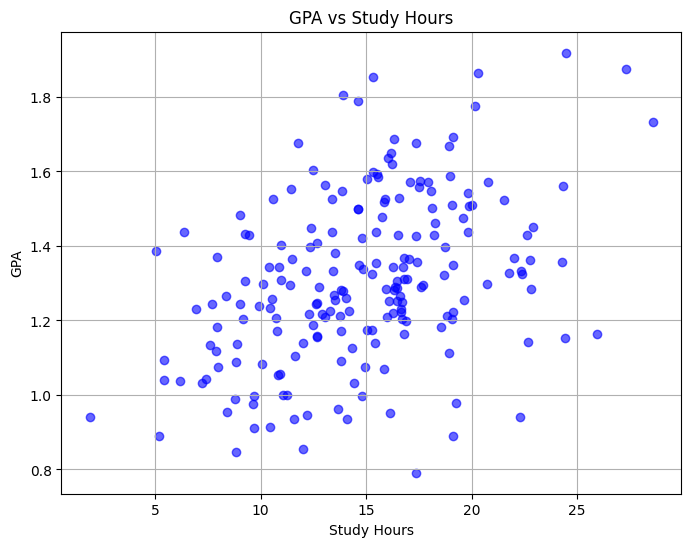

In [ ]:
# Scatter plot for GPA vs Study Hours
plt.figure(figsize=(8, 6))
plt.scatter(students_data['Study_Hours'], students_data['GPA'], color='blue', alpha=0.6)
plt.title('GPA vs Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

### Scatter Plot: GPA vs Sleep Hours

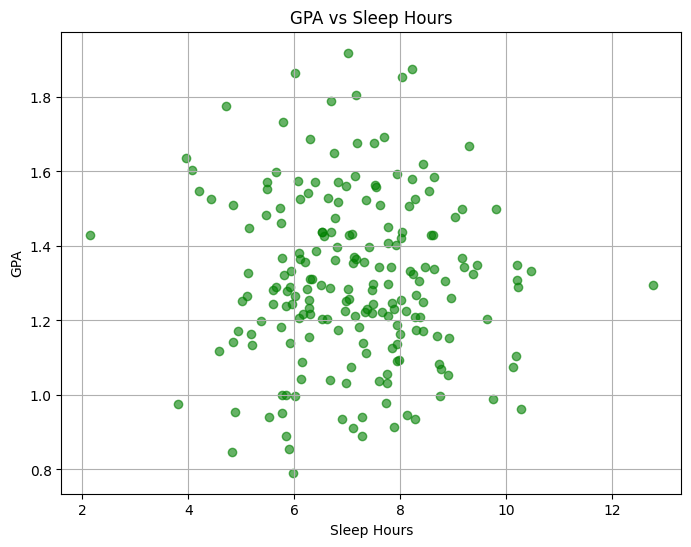

In [ ]:
# Scatter plot for GPA vs Sleep Hours
plt.figure(figsize=(8, 6))
plt.scatter(students_data['Sleep_Hours'], students_data['GPA'], color='green', alpha=0.6)
plt.title('GPA vs Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('GPA')
plt.grid(True)
plt.show()


### Scatter Plot: GPA vs Exercise Hours

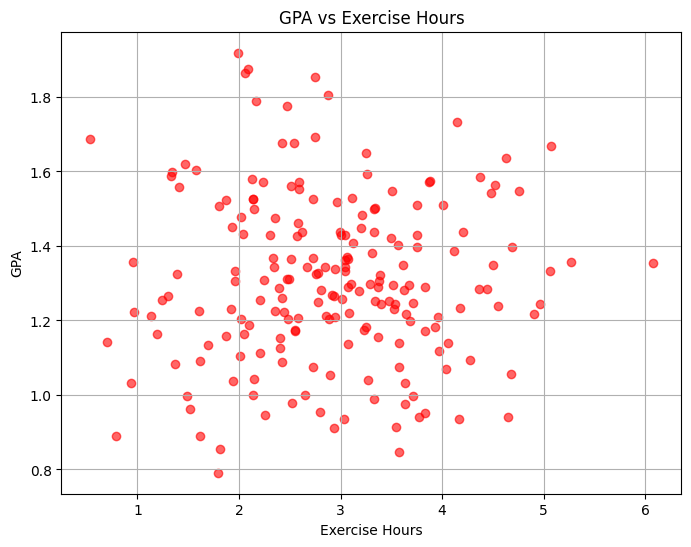

In [ ]:
# Scatter plot for GPA vs Exercise Hours
plt.figure(figsize=(8, 6))
plt.scatter(students_data['Exercise_Hours'], students_data['GPA'], color='red', alpha=0.6)
plt.title('GPA vs Exercise Hours')
plt.xlabel('Exercise Hours')
plt.ylabel('GPA')
plt.grid(True)
plt.show()


### Scatter Plot: GPA vs Attendance

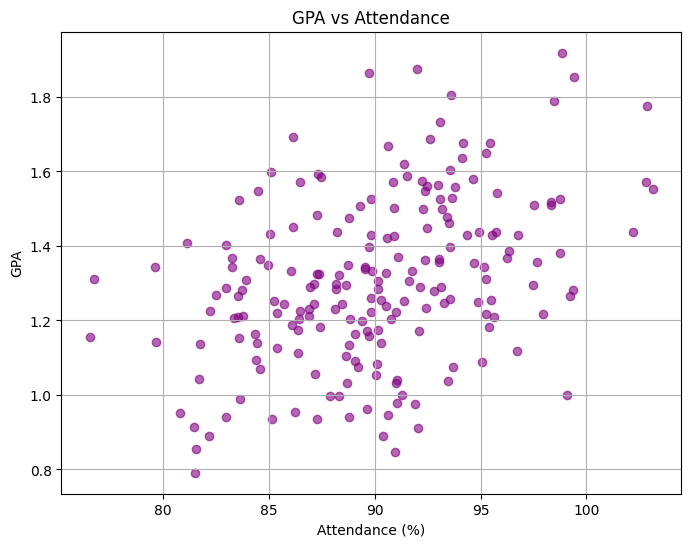

In [ ]:
# Scatter plot for GPA vs Attendance
plt.figure(figsize=(8, 6))
plt.scatter(students_data['Attendance'], students_data['GPA'], color='purple', alpha=0.6)
plt.title('GPA vs Attendance')
plt.xlabel('Attendance (%)')
plt.ylabel('GPA')
plt.grid(True)
plt.show()


### Correlation Matrix: GPA and Other Variables

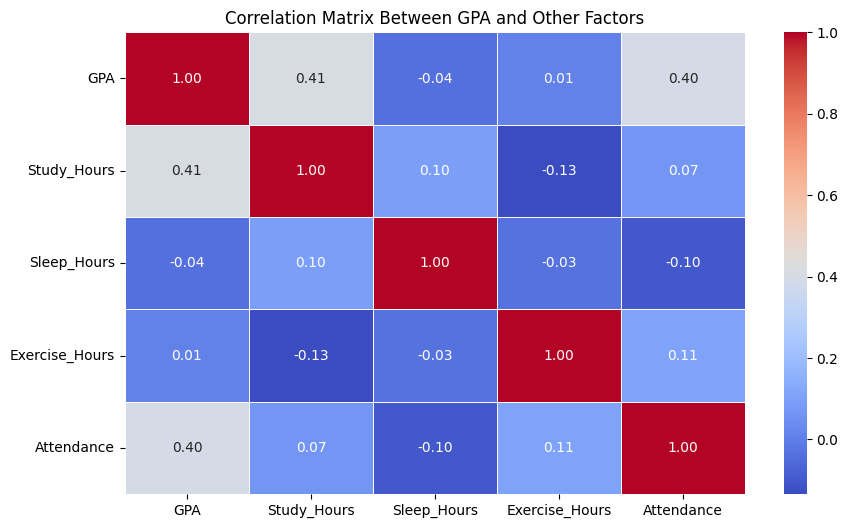

In [ ]:
# Compute correlation matrix between variables
correlation_matrix = students_data[['GPA', 'Study_Hours', 'Sleep_Hours', 'Exercise_Hours', 'Attendance']].corr()

# Plot the correlation matrix using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Between GPA and Other Factors')
plt.show()


### Box Plot: GPA by Gender

<ipython-input-28-54ee21b9cf00>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='GPA', data=students_data, palette='Set2')


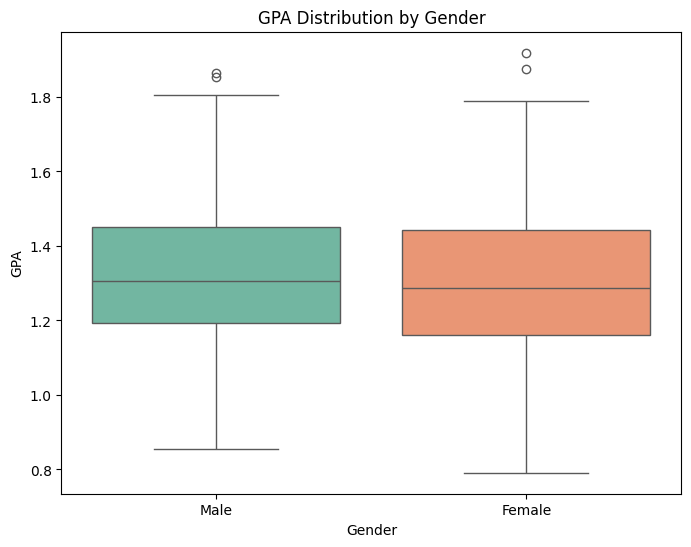

In [ ]:
# Box plot for GPA by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='GPA', data=students_data, palette='Set2')
plt.title('GPA Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('GPA')
plt.show()


---

### **IX. Conclusion**

#### **A. Summarize Key Findings**
- Study hours and attendance have significant positive correlations with GPA.
- Sleep and exercise also have some correlation, but weaker.
- The null hypothesis for gender differences in GPA was not rejected.

#### **B. Discuss Limitations**
- The sample was synthetic, and real-world biases might not have been captured.
- The sample size, while reasonable, could have been larger for more generalizable conclusions.

#### **C. Implications and Future Directions**
- Implement strategies to encourage study time for better academic performance.
- Further studies could explore the impact of other factors like nutrition or mental health on GPA.